In [27]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
from src import util_analysis 

In [9]:
import pickle 

manifest_path = "binaural_test_manifests/symmetric_distractor_conditions_neg_15_to_6_dBSNR_eval_rooms.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
    

In [10]:


room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')

In [11]:
spkr_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_room.pdpkl')

In [12]:

spkr_room_manifest

,head_azim,head_pos_xyz,index_room,is_outdoor,material_x0,material_x1,material_y0,material_y1,material_z0,material_z1,room_dim_xyz,room_materials
0,0,"[2.3, 3.6, 0.9]",0,False,"Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in","Concrete, painted",Linoleum,"Acoustic tiles, 0.625"", 16"" below ceiling","[4.66, 5.9, 2.48]","[9, 9, 9, 2, 13, 17]"
1,0,"[3.6, 2.36, 0.9]",1,False,"Fiberglass wall treatment, 1 in","Concrete, painted","Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in",Linoleum,"Acoustic tiles, 0.625"", 16"" below ceiling","[5.9, 4.66, 2.48]","[9, 2, 9, 9, 13, 17]"
2,0,"[2.36, 2.3, 0.9]",2,False,"Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in","Concrete, painted","Fiberglass wall treatment, 1 in",Linoleum,"Acoustic tiles, 0.625"", 16"" below ceiling","[4.66, 5.9, 2.48]","[9, 9, 2, 9, 13, 17]"
3,0,"[2.3, 2.3, 0.9]",3,False,"Concrete, painted","Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in",Linoleum,"Acoustic tiles, 0.625"", 16"" below ceiling","[5.9, 4.66, 2.48]","[2, 9, 9, 9, 13, 17]"


In [13]:
ls /om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004

manifest_brir.pdpkl  room0000.hdf5  room0002.hdf5
manifest_room.pdpkl  room0001.hdf5  room0003.hdf5


In [14]:
room_manifest

,head_azim,head_pos_xyz,index_room,is_outdoor,material_x0,material_x1,material_y0,material_y1,material_z0,material_z1,room_dim_xyz,room_materials
0,0,"(2.5, 2.5, 2.0)",0,False,"(Anechoic,)","(Anechoic,)","(Anechoic,)","(Anechoic,)","(Anechoic,)","(Anechoic,)","(5.0, 5.0, 4.0)","(26, 26, 26, 26, 26, 26)"
1,0,"(2.5, 2.5, 2.0)",1,False,"(Wood panelling on glass fiber blanket,)","(Wood panelling on glass fiber blanket,)","(Wood panelling on glass fiber blanket,)","(Wood panelling on glass fiber blanket,)","(Carpet on foam rubber padding,)","(Highly absorptive panels, 1"", 16"" below ceili...","(5.0, 5.0, 4.0)","(11, 11, 11, 11, 15, 20)"
2,0,"(2.5, 2.5, 2.0)",2,False,"(Brick,)","(Brick,)","(Brick,)","(Brick,)","(Wood parquet on concrete,)","(Plaster, gypsum, or lime on lath,)","(5.0, 5.0, 4.0)","(1, 1, 1, 1, 12, 16)"
3,0,"(2.5, 2.5, 2.0)",3,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(5.0, 5.0, 4.0)","(9, 9, 9, 9, 13, 17)"
4,0,"(2.5, 2.5, 2.0)",4,False,"(Concrete, painted,)","(Concrete, painted,)","(Concrete, painted,)","(Concrete, painted,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(5.0, 5.0, 4.0)","(2, 2, 2, 2, 13, 17)"
5,0,"(2.3, 3.6, 0.9)",5,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Concrete, painted,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(4.66, 5.9, 2.48)","(9, 9, 9, 2, 13, 17)"
6,0,"(2.33, 2.95, 0.9)",6,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Concrete, painted,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(4.66, 5.9, 2.48)","(9, 9, 9, 2, 13, 17)"
7,0,"(2.3, 3.6, 0.9)",7,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(4.66, 5.9, 2.48)","(9, 9, 9, 9, 13, 17)"
8,0,"(2.33, 2.95, 0.9)",8,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(4.66, 5.9, 2.48)","(9, 9, 9, 9, 13, 17)"


In [15]:
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [16]:
output_paths = list(Path(f"binaural_eval/symmetric_distractor_test/").glob("*/*room*.pkl"))


In [17]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/symmetric_distractor_test/").glob("*/*room*.pkl"))
stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    if not any(name in str(path) for name in ['word_task_half_co_loc_v07', 'word_task_v08_control_no_attn']):
        continue
    # if 'v07' not in path.as_posix() and 'v08' not in path.as_posix():
    #     continue 
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    dist_type = 'speech'
    if 'ssn' in path.stem:
        dist_type = 'noise'
    df['dist_type'] = dist_type
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('_')[1]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    
    results_dfs.append(df)

results = pd.concat(results_dfs)


In [18]:
results.loc[results.room_type == 'eval', 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

In [19]:
results.loc[results.room_type == 'mitb46', 'room_str'] = 'Standard speaker array'
results.loc[results.room_type == 'mitb46', 'room_ix'] = results.room_ix.unique().max() + 1 

In [20]:
room_material_map[results.room_ix.unique().max()] = 'Standard speaker array'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated',
 9: 'Standard speaker array'}

In [21]:
results.dist_type.unique()

array(['speech', 'noise'], dtype=object)

In [22]:
grouped_results = results.groupby(['model', 'target_azim', 'distractor_azim', 'gender_cond', 'snr', 'dist_type', 'room_ix', 'n_distractors']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]



In [23]:
### Only need 2-distrtor data 

grouped_results = grouped_results[grouped_results.n_distractors == 2]

In [24]:
### Byrne et al. 2023 data 

byrne_data = np.array([-0.09484242924828479, 0.4982925897160886,
                        5.013827763189802, -3.951329561004476,
                        10.05543433148005, -10.226709567661526,
                        19.95734556258245, -13.644653196411767,
                        39.96515321490358, -15.760526975438765,
                        0.022518913010429742, -11.306631162395057,
                        5.0401272236399315, -11.078483342990165,
                        10.065132257521036, -12.854847524768747,
                        19.96030425188309, -14.446457996885155,
                        39.8901997526207, -15.448138696779548]).reshape(-1, 2)
                        
byrne_data = pd.DataFrame({'distractor_azim':byrne_data[:,0], 'threshold_snr':byrne_data[:,1]})
byrne_data['dist_type'] = ["speech"] * 5 + ["noise"] * 5 
byrne_data['distractor_azim'] = byrne_data['distractor_azim'].astype(int).abs()
byrne_data

,distractor_azim,threshold_snr,dist_type
0,0,0.498293,speech
1,5,-3.951330,speech
2,10,-10.226710,speech
3,19,-13.644653,speech
4,39,-15.760527,speech
5,0,-11.306631,noise
6,5,-11.078483,noise
7,10,-12.854848,noise
8,19,-14.446458,noise
9,39,-15.448139,noise


In [25]:
grouped_results.columns

Index(['model', 'target_azim', 'distractor_azim', 'gender_cond', 'snr',
       'dist_type', 'room_ix', 'n_distractors', 'accuracy_mean',
       'accuracy_sem', 'confusions_mean', 'confusions_sem'],
      dtype='object')

In [26]:
outfig_dest = Path('CCN_2024/figures')
outfig_dest.mkdir(parents=True, exist_ok=True)

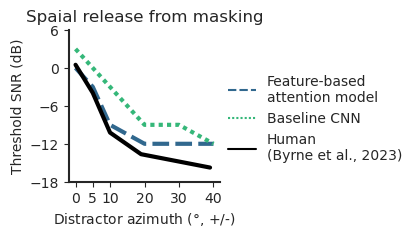

In [63]:
wanted_models = [ 'word_task_half_co_loc_v07', 'word_task_v08_control_no_attn']

model_name_dict= { 'word_task_half_co_loc_v07': "Feature-based\nattention model", 
                'word_task_v08_control_no_attn': "Baseline CNN"}

human_str = "Human\n(Byrne et al., 2023)"

model_to_plot = grouped_results[(grouped_results.model.isin(wanted_models)) & (grouped_results.room_ix.isin([0])) & (grouped_results.n_distractors == 2)].copy() #& (grouped_results.target_azim == 'center')]
model_to_plot['distractor_azim'] = model_to_plot['distractor_azim'].astype(int).abs()
model_to_plot = model_to_plot[model_to_plot.distractor_azim <= 40]

# get threshold for each target azimuth and dist_type
model_thresholds = []
for (model, azim), group in model_to_plot.groupby(['model', 'distractor_azim']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.accuracy_mean.values, threshold_value='half', bounds_from_data=True)
    if np.isnan(thresh):
        print(f"Threshold is nan for azim {azim} with model {model}")
    model_thresholds.append({'model': model, 'distractor_azim': azim, 'threshold_snr':thresh}) #  'gender_cond':gend_cond,


model_thresholds_df = pd.DataFrame(model_thresholds)


# add byrne data to model_to_plot
byrne_data['model'] = human_str
data_to_plot = pd.concat([model_thresholds, byrne_data], axis=0)
data_to_plot = data_to_plot[data_to_plot.dist_type == 'speech']
# make a palette for noise and speech where speech is black and noise is blue
# palette = {'speech':'k', 'noise':'r'}

cmap = sns.color_palette("viridis", n_colors=len(wanted_models))
palette = dict(zip(model_name_dict.values(), cmap))

palette[human_str] = 'k'

# col_order = [human_str, 'Model']
sns.set_style('ticks')
# plot 

g = sns.relplot(data=data_to_plot, x='distractor_azim', y='threshold_snr',
              #  col = 'model',# col_order=col_order,
                hue='model', palette=palette, 
                # alpha=0.5,
                style='model', style_order=[human_str] + list(model_name_dict.values()),
                kind='line', linewidth=3, zorder=5, legend=True,
                facet_kws={'sharey':False},
                errorbar=('se', 2), height=2.25, aspect=1.25, )

g.axes[0][0].set_title("Spaial release from masking")
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold SNR (dB)")
g.set_titles("{col_name}")

# plt.suptitle("Symmetric distractor positions", y=1.05)
g.set(yticks=np.arange(-18,  7, 6))
# g.legend.remove()

g._legend.set_title("")
 
# move  legend of g to the right
# g._legend.set_bbox_to_anchor([0.7, 0.75])

x_tick_locs = np.sort(model_to_plot.distractor_azim.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# save figure as svg 
# plt.tight_layout()
# plt.savefig(outfig_dest/'symmetric_distractor_thresholds.pdf', transparent=True, bbox_inches='tight')